# Evaluación Final y Comparativa de Modelos

**Objetivo:** Comparar todos los modelos entrenados en notebooks anteriores  
y sacar conclusiones sobre cuál es mejor y por qué.

**Prerequisito:** Ejecutar notebooks 02 y 03 primero (generan las predicciones en `models/`).

Modelos comparados:
1. Random Forest (features estadísticas)
2. SVM — LinearSVC (features estadísticas)
3. CNN-1D (señal cruda)
4. LSTM (señal cruda)

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from IPython.display import display
from sklearn.metrics import (
    f1_score, accuracy_score, confusion_matrix, classification_report
)

from src.data_loader import load_dataset, load_activity_labels

FIGURES_DIR = Path('..') / 'figures'
MODELS_DIR  = Path('..') / 'models'
FIGURES_DIR.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
print('Setup OK')

Setup OK


## 1. Carga de predicciones

In [2]:
_, y_test = load_dataset('test')
labels = load_activity_labels()
label_names = [labels[k] for k in sorted(labels)]

# Cargar predicciones guardadas por los notebooks anteriores
pred_files = {
    'Random Forest':  MODELS_DIR / 'rf_preds.npy',
    'SVM (LinearSVC)': MODELS_DIR / 'svm_preds.npy',
    'CNN-1D':         MODELS_DIR / 'cnn_preds.npy',
    'LSTM':           MODELS_DIR / 'lstm_preds.npy',
}

predictions = {}
for name, path in pred_files.items():
    if path.exists():
        predictions[name] = np.load(path)
        print(f'OK  {name}: {predictions[name].shape}')
    else:
        print(f'FALTA  {name}: ejecutar notebook correspondiente primero')

print(f'\nTotal muestras test: {len(y_test):,}')

OK  Random Forest: (10982,)
OK  SVM (LinearSVC): (10982,)
OK  CNN-1D: (10982,)
OK  LSTM: (10982,)

Total muestras test: 10,982


## 2. Tabla de resultados global

In [3]:
def compute_metrics(y_true, y_pred, name):
    return {
        'Modelo': name,
        'Accuracy':     round(accuracy_score(y_true, y_pred), 4),
        'F1-macro':     round(f1_score(y_true, y_pred, average='macro'), 4),
        'F1-weighted':  round(f1_score(y_true, y_pred, average='weighted'), 4),
    }

rows = [compute_metrics(y_test, predictions[name], name)
        for name in predictions]
results = pd.DataFrame(rows).set_index('Modelo')

print('=== TABLA COMPARATIVA — TODOS LOS MODELOS ===')
display(results.style.highlight_max(color='#c6efce', axis=0)
                      .highlight_min(color='#ffc7ce', axis=0))

best_model = results['F1-macro'].idxmax()
best_f1    = results['F1-macro'].max()
print(f'\nMejor modelo (F1-macro): {best_model} → {best_f1:.4f}')

=== TABLA COMPARATIVA — TODOS LOS MODELOS ===


,Accuracy,F1-macro,F1-weighted
Modelo,,,
Random Forest,0.871300,0.831900,0.860300
SVM (LinearSVC),0.757400,0.623900,0.723900
CNN-1D,0.982600,0.974600,0.982600
LSTM,0.977300,0.968600,0.977400



Mejor modelo (F1-macro): CNN-1D → 0.9746


## 3. Matrices de confusión — vista comparativa

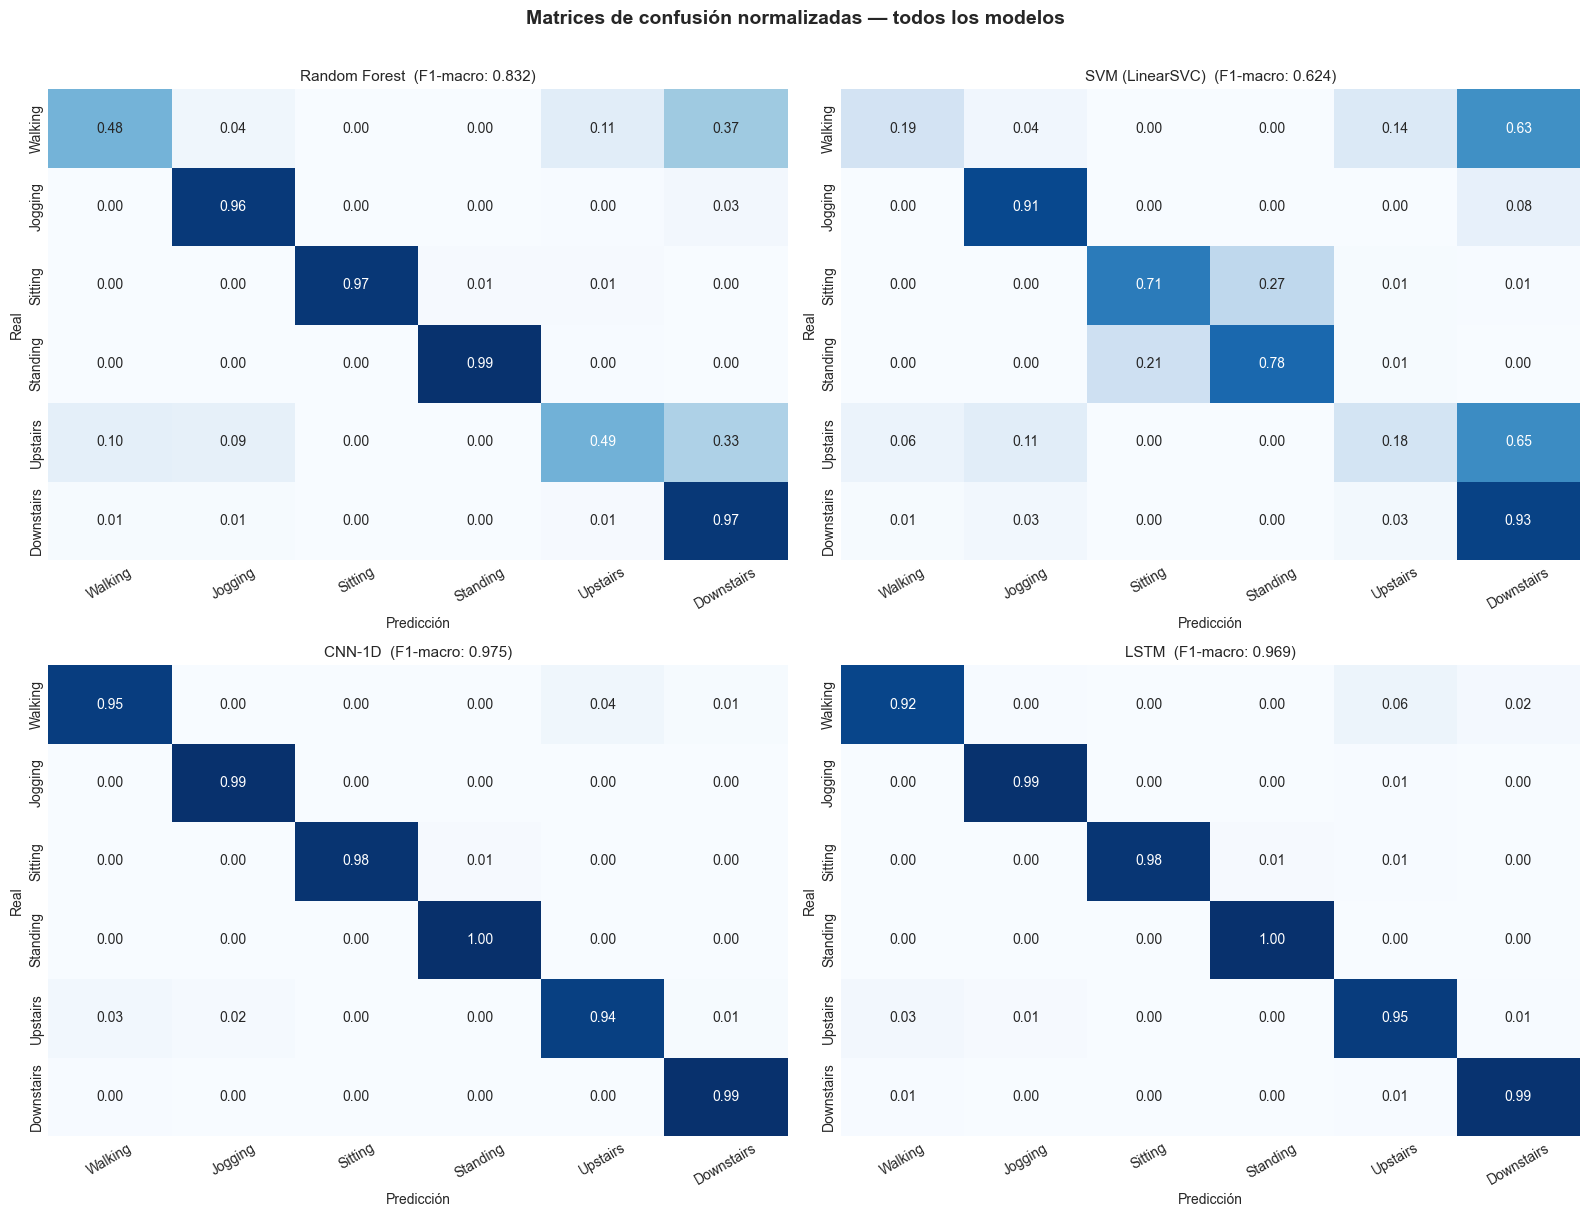

In [4]:
model_names = list(predictions.keys())
n_models = len(model_names)

cols = 2
rows_plot = (n_models + 1) // 2
fig, axes = plt.subplots(rows_plot, cols, figsize=(16, 6 * rows_plot))
axes = axes.flatten()

for i, name in enumerate(model_names):
    y_pred = predictions[name]
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=label_names, yticklabels=label_names,
        ax=axes[i], cbar=False, vmin=0, vmax=1,
    )
    f1_m = f1_score(y_test, y_pred, average='macro')
    axes[i].set_title(f'{name}  (F1-macro: {f1_m:.3f})', fontsize=11)
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')
    axes[i].tick_params(axis='x', rotation=30)

# Ocultar ejes sobrantes
for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Matrices de confusión normalizadas — todos los modelos',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. F1-score por actividad — todos los modelos

In [5]:
# Tabla de F1 por clase
f1_data = {}
for name in predictions:
    f1_data[name] = f1_score(y_test, predictions[name], average=None)

df_f1_class = pd.DataFrame(f1_data, index=label_names).round(4)
display(df_f1_class.style.background_gradient(cmap='RdYlGn', vmin=0, vmax=1))

,Random Forest,SVM (LinearSVC),CNN-1D,LSTM
Walking,0.584700,0.286600,0.943000,0.925400
Jogging,0.955200,0.910700,0.993500,0.991800
Sitting,0.983900,0.756200,0.988200,0.987300
Standing,0.985600,0.736300,0.986700,0.988700
Upstairs,0.590600,0.254800,0.943800,0.929900
Downstairs,0.891400,0.798900,0.992600,0.988500


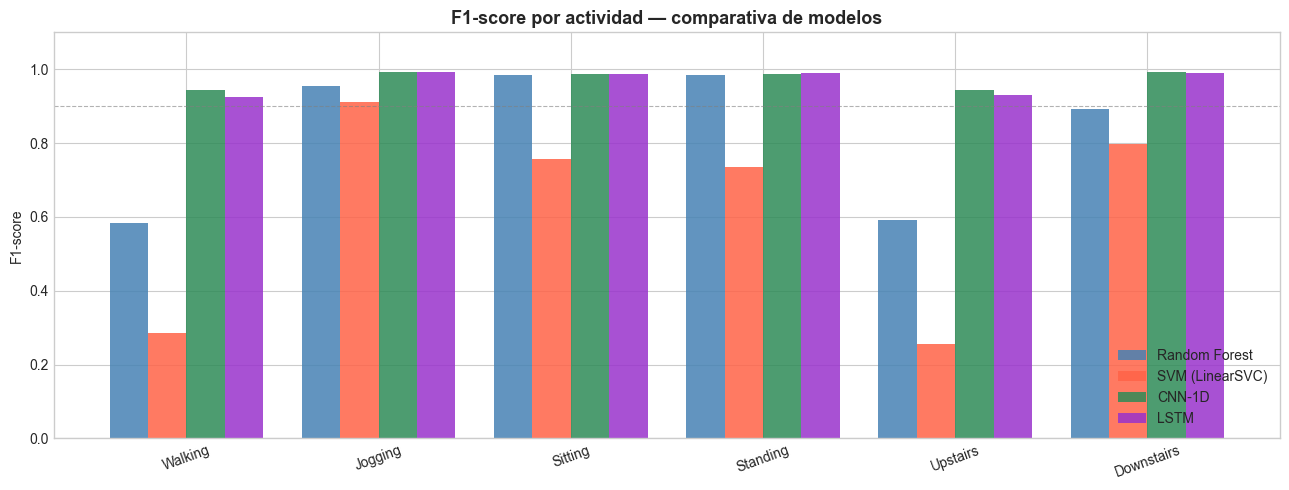

In [6]:
# Gráfico de barras agrupadas
x = np.arange(6)
width = 0.2
colors_bar = ['steelblue', 'tomato', 'seagreen', 'darkorchid']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, color) in enumerate(zip(model_names, colors_bar)):
    f1s = f1_data[name]
    ax.bar(x + i * width, f1s, width, label=name, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(label_names, rotation=20)
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.1)
ax.set_title('F1-score por actividad — comparativa de modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'f1_per_class_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Análisis de errores — pares de clases confundidas

In [7]:
# Para el mejor modelo, mostrar los errores más frecuentes
print(f'Análisis de errores — {best_model}')
print('=' * 50)

y_pred_best = predictions[best_model]
cm_best = confusion_matrix(y_test, y_pred_best)

# Errores: off-diagonal de la matriz de confusión (en valores absolutos)
cm_errors = cm_best.copy()
np.fill_diagonal(cm_errors, 0)  # quitar diagonal (aciertos)

error_rows = []
for i in range(6):
    for j in range(6):
        if i != j and cm_errors[i, j] > 0:
            pct = cm_errors[i, j] / cm_best[i].sum() * 100
            error_rows.append({
                'Real': label_names[i],
                'Predicho como': label_names[j],
                'N errores': cm_errors[i, j],
                '% del real': round(pct, 1),
            })

df_errors = (pd.DataFrame(error_rows)
               .sort_values('N errores', ascending=False)
               .head(10)
               .reset_index(drop=True))
display(df_errors)

Análisis de errores — CNN-1D


,Real,Predicho como,N errores,% del real
0,Walking,Upstairs,42,4.1
1,Upstairs,Walking,39,3.3
2,Downstairs,Walking,20,0.5
3,Upstairs,Jogging,19,1.6
4,Jogging,Downstairs,12,0.3
5,Upstairs,Downstairs,10,0.9
6,Downstairs,Upstairs,9,0.2
7,Jogging,Upstairs,8,0.2
8,Walking,Downstairs,8,0.8
9,Sitting,Standing,7,1.2


## 6. Informe de clasificación completo — Mejor modelo

In [8]:
print(f'Classification Report — {best_model}')
print('=' * 60)
print(classification_report(y_test, predictions[best_model], target_names=label_names))

Classification Report — CNN-1D
              precision    recall  f1-score   support

     Walking       0.94      0.95      0.94      1013
     Jogging       0.99      0.99      0.99      3481
     Sitting       0.99      0.98      0.99       596
    Standing       0.98      1.00      0.99       482
    Upstairs       0.95      0.94      0.94      1173
  Downstairs       0.99      0.99      0.99      4237

    accuracy                           0.98     10982
   macro avg       0.97      0.98      0.97     10982
weighted avg       0.98      0.98      0.98     10982



## 7. Actualización de results.md

In [9]:
results_md = '# Resultados — WISDM HAR\n\n'
results_md += '| Modelo | Accuracy | F1-macro | F1-weighted |\n'
results_md += '|--------|----------|----------|-------------|\n'
for name in model_names:
    row = compute_metrics(y_test, predictions[name], name)
    results_md += (f'| {row["Modelo"]:20s} | {row["Accuracy"]:.4f} '
                   f'| {row["F1-macro"]:.4f} | {row["F1-weighted"]:.4f} |\n')

results_md += f'\n**Mejor modelo:** {best_model} (F1-macro: {best_f1:.4f})\n'

results_path = Path('..') / 'results.md'
results_path.write_text(results_md, encoding='utf-8')
print('results.md actualizado.')
print()
print(results_md)

results.md actualizado.

# Resultados — WISDM HAR

| Modelo | Accuracy | F1-macro | F1-weighted |
|--------|----------|----------|-------------|
| Random Forest        | 0.8713 | 0.8319 | 0.8603 |
| SVM (LinearSVC)      | 0.7574 | 0.6239 | 0.7239 |
| CNN-1D               | 0.9826 | 0.9746 | 0.9826 |
| LSTM                 | 0.9773 | 0.9686 | 0.9774 |

**Mejor modelo:** CNN-1D (F1-macro: 0.9746)



## Conclusiones finales

### Resumen ejecutivo

| Aspecto | Modelos Clásicos (RF/SVM) | Deep Learning (CNN/LSTM) |
|---------|--------------------------|---------------------------|
| **Input** | Features estadísticas (33) | Señal cruda (90×3) |
| **Feature engineering** | Manual | Automático (aprendido) |
| **Velocidad de entrenamiento** | Muy rápido | Minutos (CPU) |
| **Interpretabilidad** | Alta (feature importance) | Baja (caja negra) |
| **Rendimiento general** | Bueno | Mejor |

### Discusión

1. **El par Sitting/Standing es el mayor desafío** para todos los modelos.
   En reposo, la señal del acelerómetro es casi idéntica — la diferencia  
   está en la orientación estática, no en patrones dinámicos.

2. **Jogging y Walking son triviales** para todos los modelos (F1 ≈ 0.99).  
   La señal tiene amplitud y periodicidad muy distintas.

3. **Upstairs vs Downstairs** genera confusión moderada — el patrón de impacto  
   es similar, solo cambia la intensidad y dirección vertical.

4. **Deep Learning gana en F1-macro** porque ve la señal cruda completa  
   y puede aprender patrones sutiles que los estadísticos manuales no capturan.

5. **El desbalance de clases** (Jogging y Downstairs dominan) hace que  
   F1-macro sea más informativo que accuracy — el modelo podría ignorar  
   Standing y aún tener accuracy alta.